In [1]:
from elastica._calculus import _isnan_check
from elastica.timestepper import extend_stepper_interface
from elastica import *
from elastica.rod.ribbon1D import Ribbon1D
from elastica.rod.linear_ribbon1D import LinearRibbon1D


from elastica._linalg import _batch_norm
from elastica._linalg import _batch_cross

import os
from elastica._rotations import _get_rotation_matrix

from itertools import groupby

import pickle
import numpy as np
import plotly.graph_objects as go
import pandas as pd
from collections import defaultdict
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from elastica.src_plotting_ribbon import *
from create_sim_env import *

%matplotlib inline


C:\Users\pmaillar\Desktop\Ribbon_interaction_pyelastica\Ribbon_interaction\elastica\src_plotting_ribbon.py:142: SyntaxWarning: invalid escape sequence '\s'
  fl = pd.read_table(path_s, nrows=0, sep='\s+')
C:\Users\pmaillar\Desktop\Ribbon_interaction_pyelastica\Ribbon_interaction\elastica\src_plotting_ribbon.py:152: SyntaxWarning: invalid escape sequence '\s'
  sol_raw = pd.read_csv(path_s, sep='\s+', header=None, on_bad_lines='skip', skipinitialspace=True)


## Sim initialization

In [ ]:
class RibbonSimulator_withOgden(BaseSystemCollection, Constraints, MemoryBlockConnections, Forcing, CallBacks):
    pass


ribbon_bollean = 1    
n_elem = 50
start = np.array([0.0, 0.0, 0.0])
direction = np.array([1.0, 0.0, 0.0])
normal = np.array([0.0, 1.0, 0.0])
base_length = 50
thickness = 0.1
width = 5.0
base_area = width*thickness
density = 1.017e-5
nu = 1e-5
E = 2.77e0
poisson_ratio = 0.34
shear_modulus = E / (2*(poisson_ratio + 1.0))
#shear_modulus = E 

dl = base_length / n_elem
dt = 1e-5

origin_force = np.array([0.0, 0.0, 0.0])
end_force = np.array([0.0, -2.3e-06, -0.00023])
ramp_up_time = 15.0



Ribbon_Ogden = RibbonSimulator_withOgden()


if ribbon_bollean==1:
    filename = "elastic_ribbon.pickle"
    ribbon = Ribbon1D.straight_ribbon(
        n_elem,
        start,
        direction,
        normal,
        base_length,
        thickness,
        width,
        density,
        youngs_modulus=E,
        shear_modulus=shear_modulus,
        poisson_ratio = poisson_ratio,
        nu = nu,
    )
    Ribbon_Ogden.append(ribbon)

elif ribbon_bollean == 2:
    filename = "linear_ribbon.pickle"
    ribbon = LinearRibbon1D.straight_ribbon(
        n_elem,
        start,
        direction,
        normal,
        base_length,
        thickness,
        width,
        density,
        youngs_modulus=E,
        shear_modulus=shear_modulus,
        poisson_ratio = poisson_ratio,
        nu = nu,
    )
    Ribbon_Ogden.append(ribbon)

else:
    filename = "elastic_rod.pickle"
    ribbon = CosseratRod.straight_rod(
        n_elem,
        start,
        direction,
        normal,
        base_length,
        thickness,
        density,
        youngs_modulus=E,
        shear_modulus=shear_modulus,
        poisson_ratio = poisson_ratio,
        nu = nu,
    )
    Ribbon_Ogden.append(ribbon)    


Ribbon_Ogden.constrain(ribbon).using(
    DampingFilterBC,
    constrained_position_idx=(0,),
    constrained_director_idx=(0,),
    filter_order=5,  # 10,
)


Ribbon_Ogden.constrain(ribbon).using(
    OneEndFixedRod, constrained_position_idx=(0,), constrained_director_idx=(0,)
)
Ribbon_Ogden.add_forcing_to(ribbon).using(
    EndpointForces, origin_force, end_force, ramp_up_time=ramp_up_time
)

gravitational_acc = -9.80665*0
Ribbon_Ogden.add_forcing_to(ribbon).using(
    GravityForces, acc_gravity=np.array([0.0, gravitational_acc, 0.0])
)



In [ ]:
class RibbonOgdenCallBack(CallBackBaseClass):
    """
    Call back function for Bean Ogeden penetration
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
#            self.callback_params["avg_velocity"].append(
#                system.compute_velocity_center_of_mass()
#            )

#            self.callback_params["center_of_mass"].append(
#                system.compute_position_center_of_mass()
#            )
            self.callback_params["curvature"].append(system.kappa.copy())
            self.callback_params["sigma"].append(system.sigma.copy())
            self.callback_params["internal_stress"].append(system.internal_stress.copy())
            self.callback_params["internal_couple"].append(system.internal_couple.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            
            return


step_skip=10000
pp_list = defaultdict(list)
Ribbon_Ogden.collect_diagnostics(ribbon).using(
    RibbonOgdenCallBack, step_skip=step_skip, callback_params=pp_list
)
print("Callback function added to the simulator")

In [ ]:
Ribbon_Ogden.finalize()
print("System finalized")

In [ ]:
final_time = 2.0
total_steps = int(final_time / dt)
print("Total steps to take", total_steps)

timestepper = PositionVerlet()

In [ ]:
integrate(timestepper, Ribbon_Ogden, final_time, total_steps)

positions_over_time = np.array(pp_list["position"])
if (np.isnan(positions_over_time)==False).all()==False:
    print("Simulation diverge. Try lowering time step !")

## Post processing

In [ ]:
with open(filename, 'wb') as handle:
    pickle.dump(pp_list, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [ ]:
with open(filename, 'rb') as handle:
    pp_list_read = pickle.load(handle)


In [ ]:
with open("linear_ribbon.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solution_1 = process_solution_data(pp_list_read, step_skip=step_skip, base_length=base_length)

with open("elastic_ribbon.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solution_2 = process_solution_data(pp_list_read, step_skip=step_skip, base_length=base_length)

In [ ]:
fig = plot_3D_ribbons_from_process_solutions(solution_1, [0,199] , solution_2 ,[0,199], n_arrows=3, save_path="figure/3D_ribbons_compare.png")

In [ ]:
fig = plot_3D_ribbons_from_process_solution(solution_2, solution_indices=[0,40,80,120,199],n_arrows = 3)

In [ ]:
with open("linear_ribbon.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)

with open("elastic_ribbon.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_2 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)


fig = plot_multiple_solutions(
    solution_dfs=[solution_1, solution_2],
    labels=["Linear Ribbon"],
    indices=[10,30,50,70,90,110,130,150], 
)

fig = plot_multiple_solutions(
    solution_dfs=[solution_2],
    labels=["Elastic Ribbon"],
    indices=[10,30,50,70,90,110,130,150], 
    start_color_idx=2,
)


fig = plot_multiple_solutions(
    solution_dfs=[solution_1, solution_2],
    labels=["Linear Ribbon","Elastic Ribbon"],
    indices=[10,50,90,130,150], 
    start_color_idx=1,
)



# Test BC and relaxation for navigation

## Setup sim

In [160]:
Y = 2.77e1
a = 5
t = 0.1
L = 50


force_newton = np.array([0.0, 1.0e-4, 1.0e-4])
force_adimentional = force_newton / (Y * a * t**3 / 12 / L**2)
print(force_adimentional)

force_adimentional = np.array([0.0, 15, 0.15])
force_newton = force_adimentional * (Y * a * t**3 / 12 / L**2)

print(force_newton)

[ 0.         21.66064982 21.66064982]
[0.000e+00 6.925e-05 6.925e-07]


In [161]:
direction = np.array([1,0,0])
normal = np.array([0,1,0])
final_time = 5
all_n_elem = np.array([10])
dt = 3e-6
base_length = L


for idx, n_elem in enumerate(all_n_elem):

    
    d2_initial = np.repeat(normal.reshape(3, 1), n_elem, axis=1)
    initial_position = np.array([np.linspace(0,1,n_elem+1)*base_length,np.zeros(n_elem+1),np.zeros(n_elem+1)])
    

    running = True
    while running:
        ribbon_output_list, Ribbon_sim = create_env_torsional_buckling(initial_position, d2_initial, dt = dt, 
                                                                       tip_force = force_newton, ramp_up_time = 0.005, nu = 3e0,
                                                                        base_length = base_length, thickness = t, width = a, 
                                                                        E = Y, poisson_ratio = 0.34, density = 1.017e-7, 
                                                                        final_time = final_time)
        timestepper = PositionVerlet()
        total_steps = int(final_time / dt)
        nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)
        
        if nan_detected:
            dt /=1.2
            print("New dt:",dt)
        else:
            running = False
            
        if dt<=1e-9:
            running = False
            print("dt set below tolerance. Break simulation")

        with open(f"simulation_data_{idx}.pickle", 'wb') as handle:
            pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
    

  0%|          | 50/1666666 [00:00<03:20, 8327.98it/s]


NaN detected at step 50 in system.
Final time of simulation is :  0.0001530000612000244
New dt: 2.5e-06


  0%|          | 84/1999999 [00:00<02:22, 13997.12it/s]


NaN detected at step 84 in system.
Final time of simulation is :  0.00021250010625005407
New dt: 2.0833333333333334e-06


  0%|          | 37/2400000 [00:00<03:14, 12358.78it/s]


...

NaN detected at step 418 in system.

  0%|          | 418/14860167 [00:00<19:03, 12999.61it/s]



Final time of simulation is :  0.0001409809189896729
New dt: 2.803916369615379e-07


 19%|█▉        | 3366976/17832200 [04:16<18:20, 13145.20it/s]


KeyboardInterrupt: 

## Post-processing

In [ ]:
with open("simulation_data_0.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, base_length=base_length)


In [ ]:
plot_multiple_solutions(
    solution_dfs=[solution_1],
    labels=["Linear Ribbon"],
    indices=np.linspace(1,solution_1.Index_solution.max(),100,dtype=np.int64))

In [ ]:
sanity_check_plot(solution_1)

In [ ]:
solution_1[solution_1.s == 1].R2.plot()
plt.show()

In [159]:
indices = ((np.logspace(0.0,2,20)*solution_1.Index_solution.max() - solution_1.Index_solution.max())/100).astype(int)

plot_3D_ribbons_from_process_solution(
    solution_1, solution_indices=indices,
    n_arrows = 3,half_width=0.1)


In [85]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from typing import Tuple


def compute_error_vector(curve1_df: pd.DataFrame,
                         curve2_df: pd.DataFrame):

    # Get s values from curve1 that will be used for interpolation
    s_values = curve1_df['s'].values
    
    # Create interpolators for each coordinate of curve2
    interpolators = {}
    for col in ['X','Y','Z']:
        # Use cubic interpolation if enough points, otherwise linear
        kind = 'cubic'
        interpolators[col] = interp1d(curve2_df['s'], curve2_df[col], kind=kind, bounds_error=False, fill_value="extrapolate")
    
    # Interpolate curve2 at the s values of curve1
    interpolated_points = np.zeros((len(s_values), len(['X','Y','Z'])))
    for i, col in enumerate(['X','Y','Z']):
        interpolated_points[:, i] = interpolators[col](s_values)
    

    curve1_points = curve1_in_range[['X','Y','Z']].values
    
    # Compute the error vectors
    error_vectors = curve1_points - interpolated_points
    
    return error_vectors, s_values



# Example usage

curve1_df = solutions_auto = pd.read_csv('solution_auto.csv')

with open("simulation_data_0.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
    
curve2_df = process_solution_elastica(pp_list_read, base_length=50)


# Compute the error vectors
error_vectors, s_values = compute_error_vector(curve1_df, curve2_df)

plt.plot(np.norm(error_vectors))

ValueError: Expect x to not have duplicates

## Compare solutions auto vs elastica

In [ ]:
step_skip=10000
base_length = 50

with open("simulation_data.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solutions_elastica = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)

with open("simulation_data_linear.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solutions_elastica_linear = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)


solutions_auto = pd.read_csv('solution_auto.csv')

temp1 = solutions_auto.Y
temp2 = solutions_auto.Z 
solutions_auto.Y = temp2
solutions_auto.Z = temp1

temp1 = solutions_auto.d1y
temp2 = solutions_auto.d1z 
solutions_auto.d1y = temp2
solutions_auto.d1z = temp1

temp1 = solutions_auto.d2y
temp2 = solutions_auto.d2z 
solutions_auto.d2y = temp2
solutions_auto.d2z = temp1

temp1 = solutions_auto.d3y
temp2 = solutions_auto.d3z 
solutions_auto.d3y = temp2
solutions_auto.d3z = temp1

In [ ]:
solutions_elastica[solutions_elastica.Index_solution == 1] = solutions_elastica[solutions_elastica.Index_solution == solutions_elastica.Index_solution.max()]
solutions_auto[solutions_auto.Index_solution == 1] = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
solutions_elastica_linear[solutions_elastica_linear.Index_solution == 1] = solutions_elastica_linear[solutions_elastica_linear.Index_solution == solutions_elastica_linear.Index_solution.max()]


plot_multiple_solutions([solutions_elastica,solutions_elastica_linear,solutions_auto], ['Elastica solver','Elastica solver (linear model)','Auto solver'], 
                        [[1,solutions_elastica.Index_solution.max()],[1,solutions_elastica_linear.Index_solution.max()],[1,solutions_auto.Index_solution.max()]], 
                        start_color_idx=0, true_solution=None, print_legend = True)

In [ ]:

solution_auto_unique = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
solution_elastica_unique = solutions_elastica[solutions_elastica.time==solutions_elastica.time.max()]

In [ ]:
plot = plot_3D_ribbons_from_process_solutions(solutions_auto, [solutions_auto.Index_solution.max()], solutions_elastica_linear, [solutions_elastica_linear.Index_solution.max()], 
                                           n_points=20, half_width=0.1, n_arrows=2)

In [ ]:
fig = plot_3D_ribbons_from_process_solution(
    solutions_elastica_linear, solution_indices=[solutions_elastica_linear.Index_solution.max()],
    n_arrows = 3,half_width=0.1)

In [ ]:
fig = plot_3D_ribbons_from_process_solution(
    solutions_auto, solution_indices=[solutions_auto.Index_solution.max()],
    n_arrows = 3,half_width=0.1)

In [ ]:
solutions_auto.s = 1
solutions_elastica_linear.s = 1
solutions_elastica.s = 1

plot = plot_3D_ribbons_from_process_solutions(solutions_auto, [solutions_auto.Index_solution.max()], solutions_elastica, [solutions_elastica.Index_solution.max()], 
                                           n_points=20, half_width=0.1, n_arrows=1,  color_df1 = 'twilight', color_df2 = 'hsv')

In [ ]:
fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='X', ax=ax, label='Auto Solution', title = 'centerline X coordinate')
solution_elastica_unique.plot(x='s', y='X', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Y', ax=ax, label='Auto Solution', title = 'centerline Y coordinate')
solution_elastica_unique.plot(x='s', y='Y', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Z', ax=ax, label='Auto Solution', title = 'centerline Z coordinate')
solution_elastica_unique.plot(x='s', y='Z', ax=ax, label='Elastica Solution')

plt.show()



print("relative error on X at the tip:", 100*abs(solution_auto_unique.X.iloc[-1]-solution_elastica_unique.X.iloc[-1])/solution_auto_unique.X.iloc[-1],"%")
print("relative error on Y at the tip:", 100*abs(solution_auto_unique.Z.iloc[-1]-solution_elastica_unique.Y.iloc[-1])/solution_auto_unique.Y.iloc[-1],"%")
print("relative error on Z at the tip:", 100*abs(solution_auto_unique.Y.iloc[-1]-solution_elastica_unique.Z.iloc[-1])/solution_auto_unique.Y.iloc[-1],"%")

In [ ]:
fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3x', ax=ax, label='Auto Solution', title = 'd3 X coordinate')
solution_elastica_unique.plot(x='s', y='d3x', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3z', ax=ax, label='Auto Solution', title = 'd3 Y coordinate')
solution_elastica_unique.plot(x='s', y='d3y', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3y', ax=ax, label='Auto Solution', title = 'd3 Z coordinate')
solution_elastica_unique.plot(x='s', y='d3z', ax=ax, label='Elastica Solution')

plt.show()

In [ ]:
with open("simulation_data.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)

solutions_auto = pd.read_csv('solution_auto_coupling.csv')

temp1 = solutions_auto.Y
temp2 = solutions_auto.Z 
solutions_auto.Y = temp2
solutions_auto.Z = temp1


solution_auto_unique = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
solution_elastica_unique = solution_1[solution_1.time==solution_1.time.max()]

solution_auto_unique[["X","Y","Z"]] = solution_auto_unique[["X","Y","Z"]]*base_length
solution_elastica_unique[["X","Y","Z"]] = solution_elastica_unique[["X","Y","Z"]]*base_length


fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='X', ax=ax, label='Auto Solution', title = 'centerline X coordinate [mm]')
solution_elastica_unique.plot(x='s', y='X', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Y', ax=ax, label='Auto Solution', title = 'centerline Y coordinate [mm]')
solution_elastica_unique.plot(x='s', y='Y', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Z', ax=ax, label='Auto Solution', title = 'centerline Z coordinate [mm]')
solution_elastica_unique.plot(x='s', y='Z', ax=ax, label='Elastica Solution')

plt.show()



print("relative error on X at the tip:", 100*abs(solution_auto_unique.X.iloc[-1]-solution_elastica_unique.X.iloc[-1])/solution_auto_unique.X.iloc[-1],"%")
print("relative error on Y at the tip:", 100*abs(solution_auto_unique.Y.iloc[-1]-solution_elastica_unique.Y.iloc[-1])/solution_auto_unique.Y.iloc[-1],"%")
print("relative error on Z at the tip:", 100*abs(solution_auto_unique.Z.iloc[-1]-solution_elastica_unique.Z.iloc[-1])/solution_auto_unique.Z.iloc[-1],"%")

In [ ]:
with open("simulation_data.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)

solutions_auto = pd.read_csv('solution_auto_coupling.csv')

#temp1 = solutions_auto.R2
#temp2 = solutions_auto.R3 
#solutions_auto.R2 = temp2
#solutions_auto.R3 = temp1

coeff = E*width*thickness**3/(12*base_length**2)

solutions_auto.R1 = -solutions_auto.R1*coeff
solutions_auto.R2 = solutions_auto.R2*coeff
solutions_auto.R3 = solutions_auto.R3*coeff

solution_auto_unique = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
solution_elastica_unique = solution_1[solution_1.time==solution_1.time.max()]


fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='R1', ax=ax, label='Auto Solution', title = 'R1 magnitude [N]')
solution_elastica_unique.plot(x='s', y='R1', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='R2', ax=ax, label='Auto Solution', title = 'R2 magnitude [N]')
solution_elastica_unique.plot(x='s', y='R2', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='R3', ax=ax, label='Auto Solution', title = 'R3 magnitude [N]')
solution_elastica_unique.plot(x='s', y='R3', ax=ax, label='Elastica Solution')

plt.show()



print("relative error on R1 at the tip:", 100*abs(solution_auto_unique.R1.iloc[-1]-solution_elastica_unique.R1.iloc[-1])/solution_auto_unique.R1.iloc[-1],"%")
print("relative error on R2 at the tip:", 100*abs(solution_auto_unique.R2.iloc[-1]-solution_elastica_unique.R2.iloc[-1])/solution_auto_unique.R2.iloc[-1],"%")
print("relative error on R3 at the tip:", 100*abs(solution_auto_unique.R3.iloc[-1]-solution_elastica_unique.R3.iloc[-1])/solution_auto_unique.R3.iloc[-1],"%")

In [ ]:
def Compare_3D_solutions(solutions_auto, solutions_elastica_1, solutions_elastica_2,
                         n_points=20, width=5.0e-3, L=50e-3,
                         colors_dict=None):
    """
    Plots 3D ribbons of auto and elastica solutions with different colors and labels.
    """
    # Default colors if none provided
    if colors_dict is None:
        colors_dict = {
            'auto': 'red',
            'elastica_1': 'green',
            'elastica_2': 'blue'
        }

    # Select latest solution snapshots
    auto = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
    elastica_1 = solutions_elastica_1[solutions_elastica_1.time == solutions_elastica_1.time.max()]
    elastica_2 = solutions_elastica_2[solutions_elastica_2.time == solutions_elastica_2.time.max()]

    half_width = width / 2
    ribbons_data = {
        'auto': auto,
        'elastica_1': elastica_1,
        'elastica_2': elastica_2
    }

    ribbons_surfaces = {}

    for label, data in ribbons_data.items():
        X_surf, Y_surf, Z_surf = [], [], []

        for _, row in data.iterrows():
            x, y, z = row[['X', 'Y', 'Z']].values * L

            # Try to use d2 if present, otherwise fallback to ty/-tx/tz
            if all(k in row for k in ['d2x', 'd2y', 'd2z']):
                d2 = np.array([row['d2x'], row['d2y'], row['d2z']])
            elif all(k in row for k in ['tx', 'ty', 'tz']):
                d2 = np.array([row['ty'], -row['tx'], row['tz']])
            else:
                raise ValueError(f"Missing ribbon direction vector for '{label}'.")

            d2 = d2 / np.linalg.norm(d2)

            m_values = np.linspace(-1, 1, n_points) * half_width
            width_points = np.array([np.array([x, y, z]) + m * d2 for m in m_values])

            X_surf.append(width_points[:, 0])
            Y_surf.append(width_points[:, 1])
            Z_surf.append(width_points[:, 2])

        # Store each ribbon’s surface and its color
        ribbons_surfaces[label] = {
            'X': np.array(X_surf),
            'Y': np.array(Y_surf),
            'Z': np.array(Z_surf),
            'color': colors_dict.get(label, 'gray')
        }

    plot_all_view(ribbons_surfaces, L)

    
def plot_all_view(ribbons_surfaces, L):
    """
    Plots multiple 3D ribbons with distinct colors and labels.
    """

    def plot_single_view(ax, elev, azim, title, plot_legend = False):
        handles = []
        labels = []

        for label, ribbon in ribbons_surfaces.items():
            X = ribbon['X'] * 1000
            Y = ribbon['Y'] * 1000
            Z = ribbon['Z'] * 1000
            color = ribbon['color']

            # Plot the ribbon surface
            surf = ax.plot_surface(
                Y, Z, X,
                color=color, edgecolor='none', alpha=0.9, linewidth=0, label=label
            )

            # Create a dummy patch for the legend
            patch = mpatches.Patch(color=color, label=label)
            handles.append(patch)
            labels.append(label)

        ax.set_xlabel('Y [mm]')
        ax.set_ylabel('Z [mm]')
        ax.set_zlabel('X [mm]')
        ax.view_init(elev=elev, azim=azim)
        #ax.set_xlim([-L/8 * 1000, L*7/8 * 1000])
        #ax.set_ylim([-L/8 * 1000, L*7/8 * 1000])
        ax.set_xlim([- 0* 1000, L * 1000])
        ax.set_ylim([- L* 1000, L * 1000])
        ax.set_zlim([0, L/2 * 1000])
        ax.invert_zaxis()
        ax.invert_yaxis()
        ax.set_title(title)

        ax.xaxis.set_pane_color('gray')
        ax.yaxis.set_pane_color('gray')
        ax.zaxis.set_pane_color('gray')

        # Add the legend
        if plot_legend:
            ax.legend(handles=handles, loc='upper right')

    import matplotlib.patches as mpatches
    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(131, projection='3d')
    plot_single_view(ax1, elev=22.5, azim=-45, title="Isometric View")

    ax2 = fig.add_subplot(132, projection='3d')
    plot_single_view(ax2, elev=5, azim=-90, title="Front View")

    ax3 = fig.add_subplot(133, projection='3d')
    plot_single_view(ax3, elev=5, azim=0, title="Side View", plot_legend = True)

    plt.tight_layout()
    plt.show()


In [ ]:
with open("simulation_data.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solutions_elastica_1 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)

#with open("simulation_data_linea_coupling.pickle", 'rb') as handle:
#    pp_list_read = pickle.load(handle)
#solutions_elastica_2 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)


solutions_auto = pd.read_csv('solution_auto_coupling.csv')

temp1 = solutions_auto.Y
temp2 = solutions_auto.Z 
solutions_auto.Y = temp2
solutions_auto.Z = temp1

temp1 = solutions_auto.d1y
temp2 = solutions_auto.d1z 
solutions_auto.d1y = temp2
solutions_auto.d1z = temp1

temp1 = solutions_auto.d2y
temp2 = solutions_auto.d2z 
solutions_auto.d2y = temp2
solutions_auto.d2z = temp1

temp1 = solutions_auto.d3y
temp2 = solutions_auto.d3z 
solutions_auto.d3y = temp2
solutions_auto.d3z = temp1

Compare_3D_solutions(solutions_auto, solutions_elastica_1,solutions_elastica_1,
                         n_points=40, width=5.0e-3, L=50e-3)

In [ ]:
elastica_2 = solutions_elastica_2[solutions_elastica_2.time == solutions_elastica_2.time.max()]
elastica_2

# Sleeves interaction 

In [ ]:
class LinearRod(BaseSystemCollection, Contact, Forcing, Constraints, CallBacks, Damping):
    pass

Rod = LinearRod()

n_elem = 30


start = np.array([0.0, 0.0, 0.0])
direction = np.array([1.0, 0.0, 0.0])
normal = np.array([0.0, 0.0, 1.0])
base_length = 50
thickness = 0.1
width = 5

base_area = width*thickness
density = 1.017e-7
nu = 25e1
E = 2.77e3
num_lagrange = 1e2
poisson_ratio = 0.34

w0 = (np.pi/base_length)**2*np.sqrt(E*width*thickness**3/12/(density*base_area))
print("we have 2*w0 =", 2*w0)
print("we have P = ", 2*np.pi/w0)
dt = 1.0e-8

s = np.linspace(0,1,n_elem+1)
s_bc = np.concatenate((np.array([0]),s[:-1]))
w = 2*np.pi
A = 0.1

#position = base_length*np.array([s-A*np.sin(w*s_bc),np.zeros(n_elem+1),A*np.sin(w*s_bc)])

position = base_length*np.array([s,np.zeros(n_elem+1),A*np.sin(w*s+np.pi/2)-A])

d2 = np.array([np.zeros(n_elem),np.ones(n_elem),np.zeros(n_elem)])

position_diff = position[..., 1:] - position[..., :-1]
rest_lengths = _batch_norm(position_diff)
d3 = position_diff / rest_lengths

d1 = _batch_cross(d2,d3)

d1 = d1 / _batch_norm(d1)


directors = np.stack([d1,d2,d3],axis=0)


origin_force = np.array([1.0e-5, 0.0, 0.0])*0
end_force = np.array([0.0, 2.0e-2*0, 2.0e-4])*5*0 # (x,y,z)
ramp_up_time_force = 0.05

origin_torque = np.array([0, 0.0, 0.0])
end_torque = np.array([0.0, 5.0e-4, 0.0])*0
ramp_up_time_torque = 1.0

shearable_rod = Ribbon1D.straight_ribbon(
    n_elem,
    np.zeros((3,)),
    d3[:,0],
    d1[:,0],
    base_length,
    thickness,
    width,
    density,
    youngs_modulus=E,
    shear_modulus=E*num_lagrange, # influence the shearability of the ribbon
    poisson_ratio=0.34,
    position = position,
    directors = directors,
    #nu_for_torques=damp_coefficient*((radius_mean/radius_base)**4),
)



Rod.append(shearable_rod)


""" Add damping """
Rod.dampen(shearable_rod).using(
    AnalyticalLinearDamper,
    damping_constant=nu,
    time_step=dt,
)


# Impact steady state !!! Add error when comparing with auto
#Rod.dampen(shearable_rod).using(
#         LaplaceDissipationFilter,
#         filter_order=2,   # order of the filter (geater order means less damping)
#    )




""" Set up boundary conditions """
Rod.constrain(shearable_rod).using(
    GeneralConstraint,
    constrained_position_idx=(0,),
    constrained_director_idx=(0,),
    #translational_constraint_selector=np.array([False, True, True]),  # Allow X movement, fix Y & Z
    translational_constraint_selector=np.array([True, True, True]),  # Allow X movement, fix Y & Z
    rotational_constraint_selector=np.array([True, True, True])  # Fix all rotations
)


#Rod.constrain(shearable_rod).using(
#    GeneralConstraint,
#    constrained_position_idx=(-1,),
#    constrained_director_idx=(-1,),
#    rod_frame_bool = True,
    #translational_constraint_selector=np.array([False, False, True]),  
#    translational_constraint_selector=np.array([False, False, False]),  
#    rotational_constraint_selector=np.array([False, False, False]) 
#)


Rod.add_forcing_to(shearable_rod).using(
    EndpointForces, origin_force, end_force, ramp_up_time=ramp_up_time_force
)

#Rod.add_forcing_to(shearable_rod).using(
#    EndpointTorques, origin_torque, end_torque, ramp_up_time=ramp_up_time_torque
#)


""" Set contact """
s = np.linspace(0,1,n_elem)
w = np.pi/2
#d1 = np.array([np.zeros(n_elem),np.sin(w*s),-np.cos(w*s)])

s = np.linspace(0,1,n_elem+1)
s_bc = np.concatenate((np.array([0]),s[:-1]))
w = 2*np.pi
A = 0.1

position = base_length*np.array([s_bc,np.zeros(n_elem+1),A*np.sin(w*s_bc+np.pi/2)-A])

sleeve = Sleeve(position, d1)


Rod.append(sleeve)

Rod.detect_contact_between(shearable_rod, sleeve).using(
    RibbonSleeveContact,
    k=3*1.16e-3, #k = E_0 = 3*G_0 
    nu=0,
    alpha = -16.6,
    poisson_ratio=0.5,
    width_elem = width,
    length_elem = base_length/n_elem,
    N_quad = 3,
)


In [ ]:
class RodCallBack(CallBackBaseClass):
    """
    Call back function for Bean Ogeden penetration
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
            self.callback_params["avg_velocity"].append(
                system.compute_velocity_center_of_mass()
            )
#            self.callback_params["center_of_mass"].append(
#                system.compute_position_center_of_mass()
#            )
            self.callback_params["curvature"].append(system.kappa.copy())
            self.callback_params["sigma"].append(system.sigma.copy())
            self.callback_params["internal_stress"].append(system.internal_stress.copy())
            self.callback_params["internal_couple"].append(system.internal_couple.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            self.callback_params["dilatation"].append(system.dilatation.copy())
            self.callback_params["tangents"].append(system.tangents.copy())
            
            
            return


step_skip=10000
pp_list = defaultdict(list)
Rod.collect_diagnostics(shearable_rod).using(
    RodCallBack, step_skip=step_skip, callback_params=pp_list
)

In [ ]:
Rod.finalize()
print("System finalized")

In [ ]:
final_time = 0.075
total_steps = int(final_time / dt)
print("Total steps to take", total_steps)

timestepper = PositionVerlet()

In [ ]:
integrate(timestepper, Rod, final_time, total_steps, time_display_up = 1)

positions_over_time = np.array(pp_list["position"])
if (np.isnan(positions_over_time)==False).all()==False:
    print("Simulation diverge. Try lowering time step !")

In [ ]:
with open("simulation_data.pickle", 'wb') as handle:
    pickle.dump(pp_list, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [ ]:
with open("simulation_data.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, step_skip=step_skip, base_length=base_length)


In [ ]:
d = { 's' : s_bc, 
     'X' : position[0,:]/base_length, 
     'Y' : position[1,:]/base_length, 
     'Z': position[2,:]/base_length,
     'R1': np.zeros_like(s_bc),
     'R2': np.zeros_like(s_bc),
     'R3': np.zeros_like(s_bc),
     'V1': np.zeros_like(s_bc),
     'V2': np.zeros_like(s_bc),
     'V3': np.zeros_like(s_bc)
    }
true_solution_sleeve = pd.DataFrame(data = d)
true_solution_sleeve.head()

In [ ]:
plot_multiple_solutions(
    solution_dfs=[solution_1],true_solution = true_solution_sleeve,
    labels=["Linear Ribbon"],
    indices=np.linspace(0,solution_1.Index_solution.max(),100,dtype=np.int64))

In [ ]:
sanity_check_plot(solution_1)

In [ ]:
indices = ((np.logspace(0.0,2,20)*solution_1.Index_solution.max() - solution_1.Index_solution.max())/100).astype(int)

fig = plot_3D_ribbons_from_process_solution(
    solution_1, solution_indices=indices,
    n_arrows = 3,half_width=0.1)

# Trajectory simulation 

In [162]:
def build_incremental_discretized_paths(path_df, direction, normal, n_points, M, min_length):
    """
    Build discretized paths with twist support.
    
    Parameters:
    -----------
    path_df : DataFrame
        DataFrame with columns 'type', 'length (mm)', 'curvature (1/mm)', and optionally 'twist (rad/mm)'
    direction : ndarray
        Initial direction vector
    normal : ndarray
        Initial normal vector
    n_points : int
        Number of points in the final path
    M : int
        Number of paths to generate with different lengths
    min_length : float
        Minimum path length
        
    Returns:
    --------
    all_paths : list of arrays
        List of path arrays, each with shape (3, n_points)
    lengths : ndarray
        Array of path lengths
    normals : list of arrays
        List of normal vector arrays along each path, each with shape (3, n_points)
    """
    # Normalize initial vectors
    direction = direction / np.linalg.norm(direction)
    # Make normal orthogonal to direction
    normal = normal - direction * np.dot(direction, normal)
    normal /= np.linalg.norm(normal)
    binormal = np.cross(direction, normal)
    
    # Calculate path lengths
    total_length = path_df['length (mm)'].sum()
    max_length = total_length
    lengths = np.linspace(min_length, max_length, M)
    
    all_paths = []
    all_normals = []  # Store normals along the path
    
    # Add default twist value if not present
    if 'twist (rad/mm)' not in path_df.columns:
        path_df['twist (rad/mm)'] = 0.0
        
    for target_length in lengths:
        path_points = [np.zeros(3)]
        path_normals = [normal.copy()]  # Track normals along the path
        
        pos = np.zeros(3)
        T = direction.copy()  # Tangent (direction) vector
        N = normal.copy()     # Normal vector
        B = binormal.copy()   # Binormal vector
        
        accumulated_length = 0.0
        
        for idx, row in path_df.iterrows():
            seg_type = row['type']
            L = row['length (mm)']
            k = row['curvature (1/mm)']
            twist_rate = row.get('twist (rad/mm)', 0.0)  # Twist rate in radians per mm
            
            remaining_length = target_length - accumulated_length
            if remaining_length < 0:
                break
                
            # Clip segment if needed
            seg_length = min(L, remaining_length)
            if seg_length < 1e-6:
                continue
                
            # Allocate points
            num_pts = n_points if seg_length == target_length else max(2, int(np.ceil((seg_length / target_length) * n_points)))
            ds = seg_length / (num_pts - 1)
            
            if seg_type == 'line' or np.isclose(k, 0.0):
                # Straight line segment
                for i in range(1, num_pts):
                    # Move along tangent direction
                    pos = pos + T * ds
                    
                    # Apply twist around tangent axis
                    if not np.isclose(twist_rate, 0.0):
                        twist_angle = twist_rate * ds
                        twist_matrix = rotation_matrix(T, twist_angle)
                        N = twist_matrix @ N
                        B = twist_matrix @ B
                    
                    # Ensure orthonormality of the frame
                    B = np.cross(T, N)
                    B /= np.linalg.norm(B)
                    N = np.cross(B, T)
                    N /= np.linalg.norm(N)
                    
                    path_points.append(pos.copy())
                    path_normals.append(N.copy())
                    
            else:  # arc segment
                R = 1 / k  # Radius of curvature
                theta_total = seg_length * k  # Total angle of the arc
                dtheta = theta_total / (num_pts - 1)  # Angle increment per step
                
                # Center of the arc
                center = pos + N * R
                
                for i in range(1, num_pts):
                    # Curvature rotation
                    theta = i * dtheta
                    rot_axis = B
                    curve_matrix = rotation_matrix(rot_axis, theta)
                    
                    # Calculate position from center
                    rotated_vector = curve_matrix @ (-N * R)
                    new_pos = center + rotated_vector
                    
                    # Update the frame due to curvature
                    T_new = curve_matrix @ T
                    N_new = curve_matrix @ N
                    B_new = curve_matrix @ B
                    
                    # Apply additional twist around the tangent
                    if not np.isclose(twist_rate, 0.0):
                        twist_angle = twist_rate * ds * i
                        twist_matrix = rotation_matrix(T_new, twist_angle)
                        N_new = twist_matrix @ N_new
                        B_new = twist_matrix @ B_new
                    
                    # Ensure orthonormality
                    T_new /= np.linalg.norm(T_new)
                    B_new = np.cross(T_new, N_new)
                    B_new /= np.linalg.norm(B_new)
                    N_new = np.cross(B_new, T_new)
                    N_new /= np.linalg.norm(N_new)
                    
                    # Store updated values
                    T, N, B = T_new, N_new, B_new
                    path_points.append(new_pos.copy())
                    path_normals.append(N.copy())
                
                pos = path_points[-1]
                
            accumulated_length += seg_length
            if accumulated_length >= target_length:
                break
                
        # Interpolate to ensure exactly `n_points`
        path_points = np.array(path_points)
        path_normals = np.array(path_normals)
        
        if len(path_points) > 1:
            # Calculate arc lengths
            distances = np.linalg.norm(np.diff(path_points, axis=0), axis=1)
            arc_lengths = np.insert(np.cumsum(distances), 0, 0.0)
            
            # Target arc lengths for interpolation
            target_arc = np.linspace(0, arc_lengths[-1], n_points)
            
            # Interpolate path points
            interp_path = np.zeros((n_points, 3))
            interp_normals = np.zeros((n_points, 3))
            
            for j in range(3):
                interp_path[:, j] = np.interp(target_arc, arc_lengths, path_points[:, j])
                interp_normals[:, j] = np.interp(target_arc, arc_lengths, path_normals[:, j])
            
            # Normalize the interpolated normals
            norms = np.linalg.norm(interp_normals, axis=1, keepdims=True)
            interp_normals = interp_normals / norms
            
            all_paths.append(interp_path.T)  # shape (3, n_points)
            all_normals.append(interp_normals.T)  # shape (3, n_points)
        else:
            # Handle edge case with only one point
            all_paths.append(np.tile(path_points[0], (3, n_points)))
            all_normals.append(np.tile(normal, (3, n_points)))
    
    return all_paths, lengths, all_normals

def skew(v):
    """Skew-symmetric matrix for cross product"""
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def rotation_matrix(axis, angle):
    """
    Return the rotation matrix associated with counterclockwise rotation
    about the given axis by the given angle.
    
    Uses Rodrigues' rotation formula.
    
    Parameters:
    -----------
    axis : ndarray
        The axis around which to rotate
    angle : float
        The angle of rotation in radians
        
    Returns:
    --------
    matrix : ndarray
        3x3 rotation matrix
    """
    axis = axis / np.linalg.norm(axis)
    
    return (np.cos(angle) * np.eye(3) + 
            np.sin(angle) * skew(axis) + 
            (1 - np.cos(angle)) * np.outer(axis, axis))

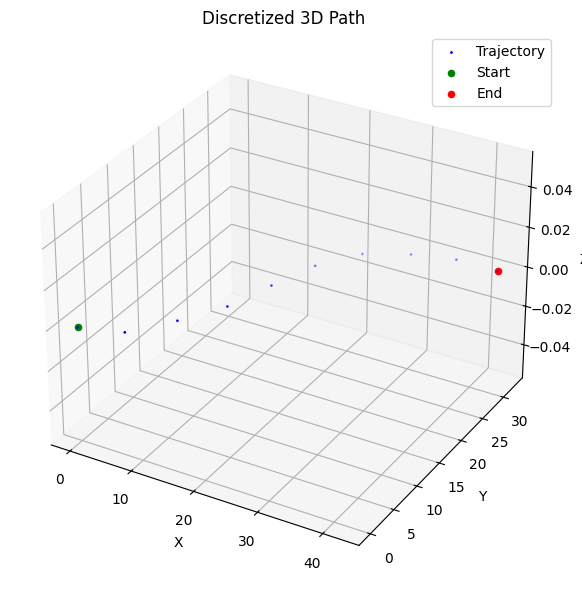

In [173]:
# Example path with twist values
data = {
    'type': ['arc', 'line', 'arc', 'line'],
    'length (mm)': [12.1, 13.8, 12.2, 9.3],
    'curvature (1/mm)': [0.0667, 0.0, -0.0667, 0.0],
    'twist (rad/mm)': [0.0, 0.0, 0.0, 0.0]  # Twist rates for each segment
}
path_df = pd.DataFrame(data)

# Initial direction and normal
direction = np.array([1.0, 0.0, 0.0])
normal = np.array([0.0, 1.0, 0.0])

# Build paths with twist
paths, lengths, normals = build_incremental_discretized_paths(
    path_df, direction, normal, n_points=10, M=5, min_length=5.0
)
plot_trajectory(paths[4])

In [166]:
N_points = 50

direction = np.array([0,-1,0])
normal = np.array([0,0,1])
path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")


M = 50 # number of step in a path
min_length = 5


paths_points, base_length = build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)
plot_trajectory(paths_points[4])

n_elem = paths_points[0].shape[1] -1 

ValueError: too many values to unpack (expected 2)

## Run simulations and Post Processing

[ 5.          9.71288067 14.42576134 19.13864201 23.85152268 28.56440335
 33.27728402 37.99016469 42.70304536 47.41592603]


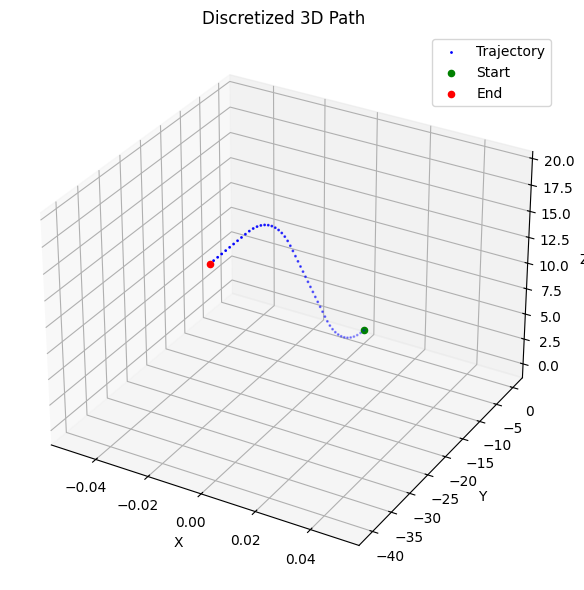

  0%|          | 44/75000 [00:00<00:13, 5506.96it/s]


NaN detected at step 44 in system.
Final time of simulation is :  4.500000000000002e-06
New dt: 8.333333333333334e-08


  0%|          | 48/89999 [00:00<00:18, 4800.35it/s]


NaN detected at step 48 in system.
Final time of simulation is :  4.083378704207825e-06
New dt: 6.944444444444445e-08


  0%|          | 49/107999 [00:00<00:24, 4452.36it/s]


...

NaN detected at step 81 in system.
Final time of simulation is :  3.295413748573337e-06
New dt: 3.348979766803842e-08


  0%|          | 78/223948 [00:00<00:20, 11133.80it/s]


NaN detected at step 78 in system.
Final time of simulation is :  2.645703466876246e-06
New dt: 2.790816472336535e-08


100%|██████████| 268738/268738 [00:34<00:00, 7725.51it/s]

Final time of simulation is :  0.007499999999950382


In [12]:
N_points = 50

direction = np.array([0,-1,0])
normal = np.array([0,0,1])
path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")
M = 10 # number of step in a path
min_length = 5
kp = 1.2
final_time = 0.075


paths_points, base_length = build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)



for idx, stat in enumerate(paths_points[-1:]):

    plot_trajectory(stat)
    
    d2_initial = np.array([np.ones(stat.shape[1]-1),np.zeros(stat.shape[1]-1),np.zeros(stat.shape[1]-1)])
    initial_position = stat 
    sleeve_position = initial_position
    d2_sleeve = d2_initial

    dt = 1e-7
    
    running = True
    while running:
        ribbon_output_list, sleeve_output_list, Ribbon_sim = create_env(initial_position, d2_initial, sleeve_position, d2_sleeve, 
                                                                        base_length = base_length[idx], dt = dt, 
                                                                        final_time = final_time, k_p_input_force = kp)
        timestepper = PositionVerlet()
        total_steps = int(final_time / dt)
        nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)
        
        if nan_detected:
            dt /=1.2
            print("New dt:",dt)
            if end_time > 1e4*dt*1.2:
                kp /=2
                print("New kp", kp)
        else:
            running = False
            
        if dt<=1e-9:
            running = False
            print("dt set below tolerance. Break simulation")

        with open(f"simulation_data_{idx}.pickle", 'wb') as handle:
            pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
        with open(f"simulation_data_sleeve_{idx}.pickle", 'wb') as handle:
            pickle.dump(sleeve_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [8]:
idx = 0

with open(f"simulation_data_{idx}.pickle", 'rb') as handle:
    ribbon_output_list_read = pickle.load(handle)

with open(f"simulation_data_sleeve_{idx}.pickle", 'rb') as handle:
    sleeve_output_list_read = pickle.load(handle)

idx = -1
solution_1 = process_solution_elastica(ribbon_output_list_read, base_length=base_length[idx])
solution_sleeve = process_solution_elastica_sleeve(sleeve_output_list_read)

In [151]:
solution_1 = all_solutions[9]
solutions_sleeve = all_solutions[9]

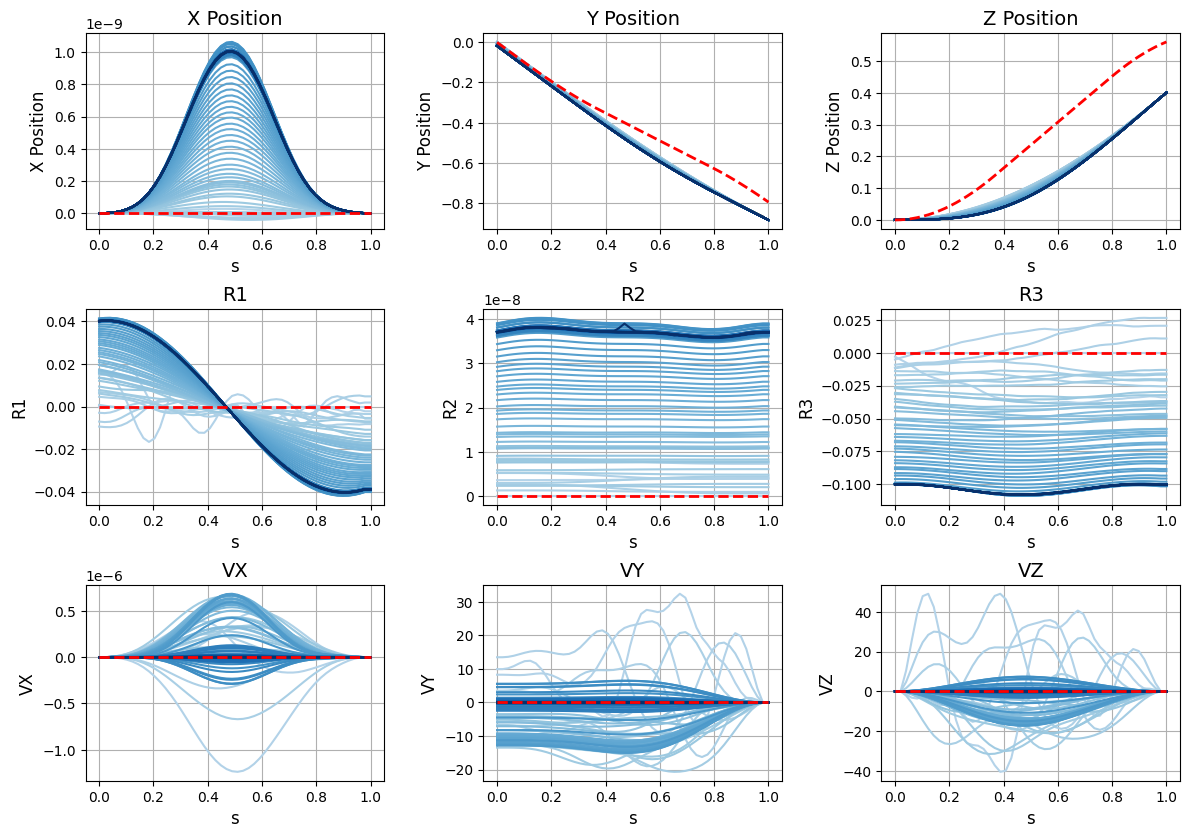

In [152]:
s = solution_1[solution_1.step ==0].s
d = { 's' : s, 
     'X' : paths_points[idx][0,:]/base_length[idx], 
     'Y' : paths_points[idx][1,:]/base_length[idx], 
     'Z': paths_points[idx][2,:]/base_length[idx],
     'R1': np.zeros_like(s),
     'R2': np.zeros_like(s),
     'R3': np.zeros_like(s),
     'VX': np.zeros_like(s),
     'VY': np.zeros_like(s),
     'VZ': np.zeros_like(s)
    }
true_solution_sleeve = pd.DataFrame(data = d)
true_solution_sleeve.head()

plot_multiple_solutions(
    solution_dfs=[solution_1],true_solution = true_solution_sleeve,
    labels=["Linear Ribbon"],
    indices=np.linspace(0,solution_1.Index_solution.max(),100,dtype=np.int64))

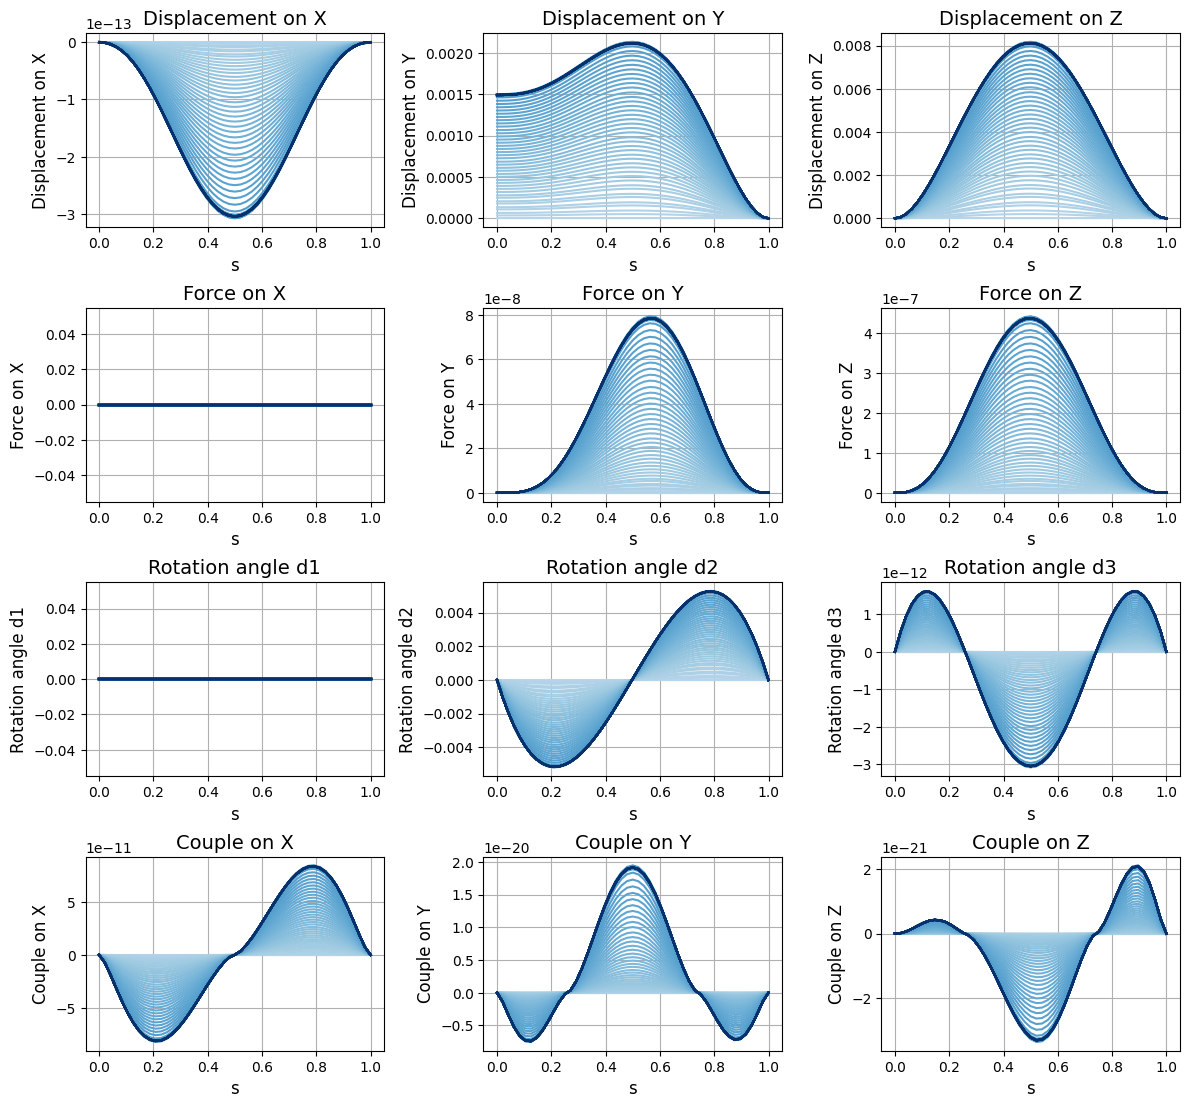

In [153]:
plot_multiple_solutions_sleeve(
    solution_dfs=[solution_sleeve],
    labels=["Sleeve"],
    indices=np.linspace(0,solution_1.Index_solution.max(),100,dtype=np.int64))

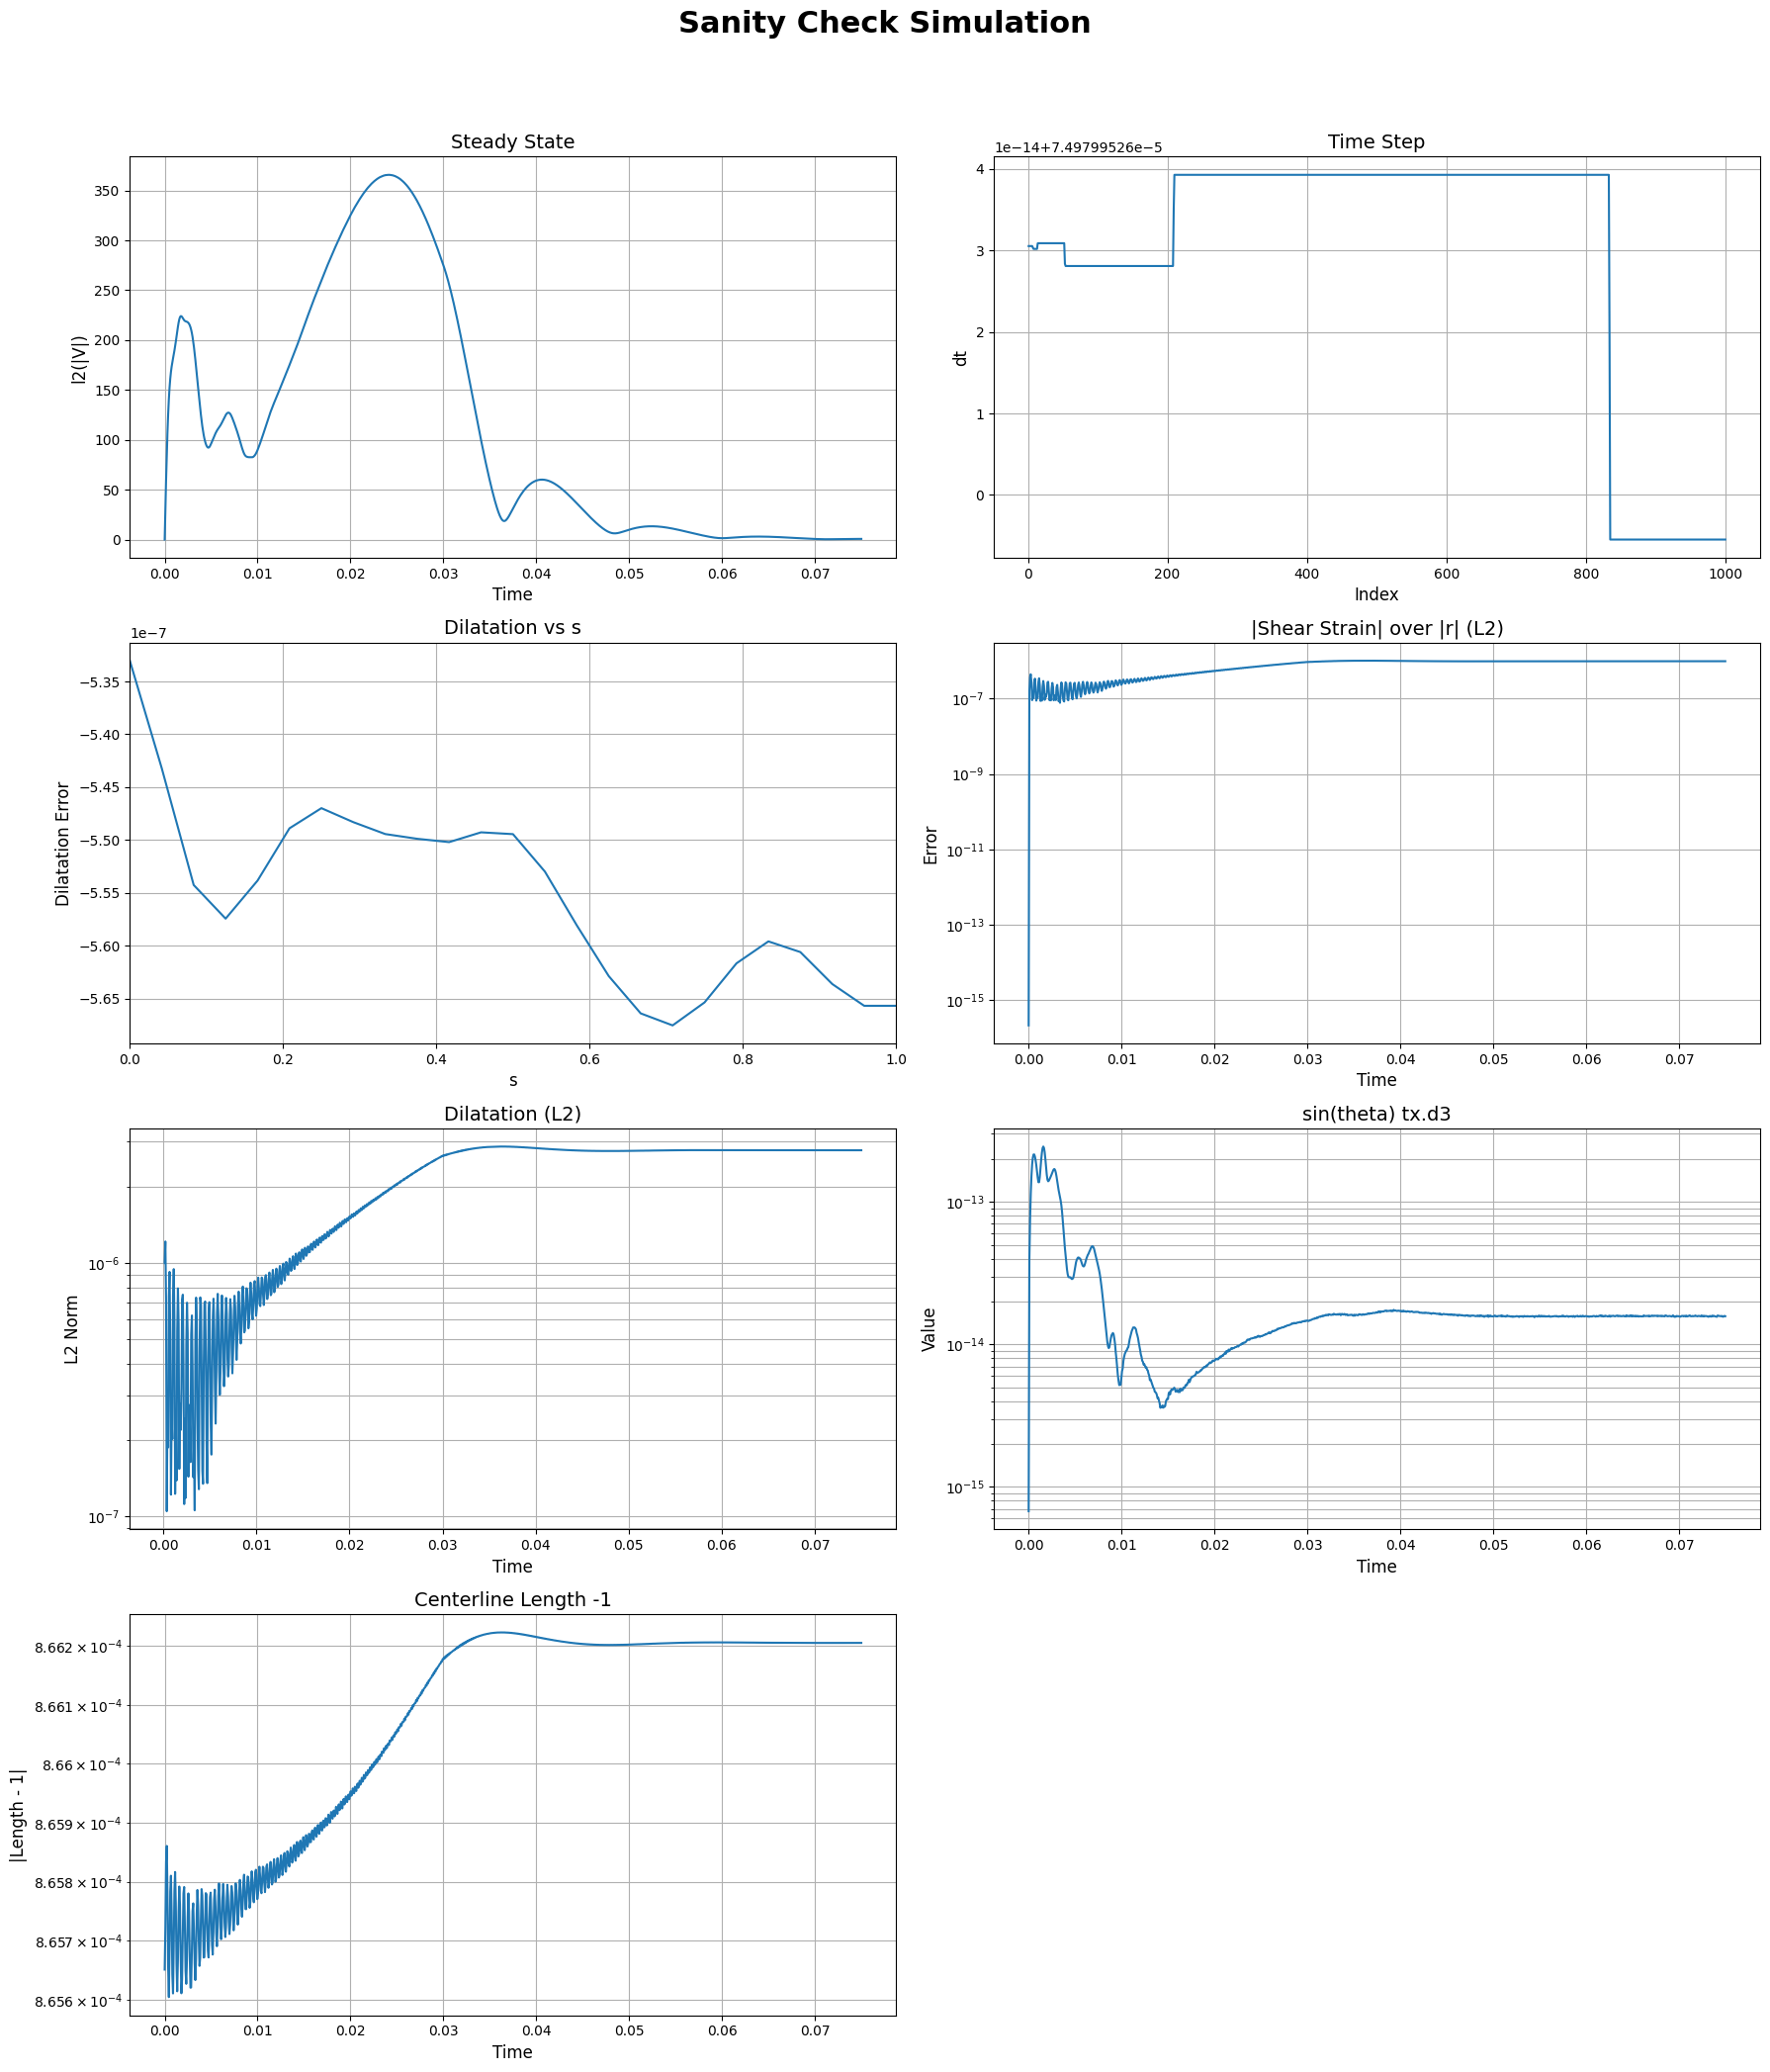

Final stress stat at s = 0:
R1: 2.8599e-02
R2: 8.7895e-05
R3: -9.8925e-02
Final stress stat at s = 1:
R1: 1.6035e-03
R2: 8.7863e-05
R3: -1.0499e-01


In [134]:
sanity_check_plot(solution_1)

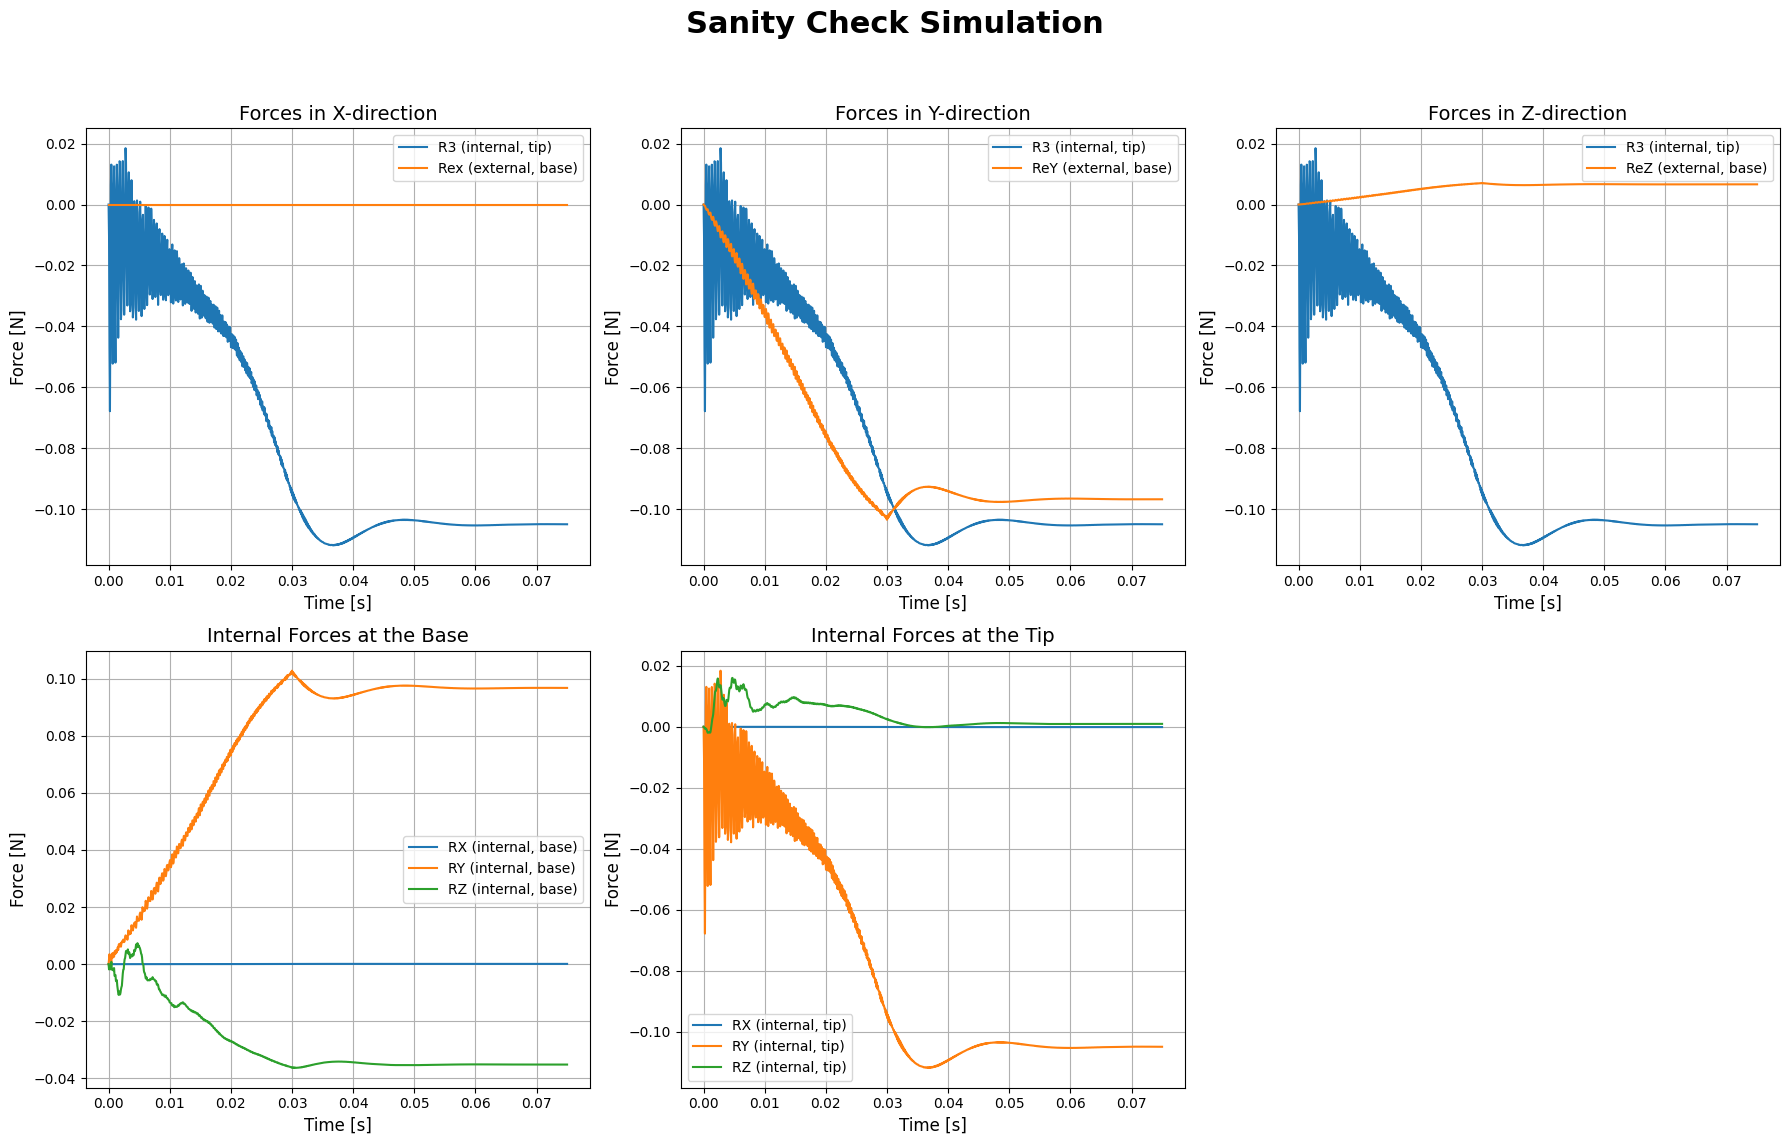

In [135]:
control_law_plot(solution_1)

In [18]:
indices = ((np.logspace(0.0,2,20)*solution_1.Index_solution.max() - solution_1.Index_solution.max())/100).astype(int)

fig = plot_3D_ribbons_from_process_solution(
    solution_1, solution_indices=indices,
    n_arrows = 3,half_width=0.1)

In [19]:
base_sol = solution_1[solution_1.s == 0]
base_sol = base_sol[base_sol.step == base_sol.step.max()]
tip_sol = solution_1[solution_1.s == 1]
tip_sol = tip_sol[tip_sol.step == tip_sol.step.max()]

sleeve_base = solution_sleeve[solution_sleeve.s == 0]
sleeve_base = sleeve_base[sleeve_base.step == sleeve_base.step.max()]

print("Base stress stat:")
print("RX:", base_sol.RX.values[0])
print("RY", base_sol.RY.values[0])
print("RZ", base_sol.RZ.values[0])
print("norm", np.sqrt(base_sol.RX**2 + base_sol.RY**2 + base_sol.RZ**2).values[0], "\n")

print("R1:", base_sol.R1.values[0])
print("R2", base_sol.R2.values[0])
print("R3", base_sol.R3.values[0])
print("norm", np.sqrt(base_sol.R1**2 + base_sol.R2**2 + base_sol.R3**2).values[0], "\n")

print("ReX:", base_sol.ReX.values[0])
print("ReY", base_sol.ReY.values[0])
print("ReZ", base_sol.ReZ.values[0])
print("norm", np.sqrt(base_sol.ReX**2 + base_sol.ReY**2 + base_sol.ReZ**2).values[0], "\n")

print("ReX_sleeve:", sleeve_base.response_force_X.values[0]/2)
print("ReY_sleeve", sleeve_base.response_force_Y.values[0]/2)
print("ReZ_sleeve", sleeve_base.response_force_Z.values[0]/2)
print("norm_sleeve", np.sqrt(sleeve_base.response_force_X**2 + sleeve_base.response_force_Y**2 + sleeve_base.response_force_Z**2).values[0], "\n")


print("Tip stress stat:")
print("RX:", tip_sol.RX.values[0])
print("RY", tip_sol.RY.values[0])
print("RZ", tip_sol.RZ.values[0])
print("norm", np.sqrt(tip_sol.RX**2 + tip_sol.RY**2 + tip_sol.RZ**2).values[0], "\n")

print("R1:", tip_sol.R1.values[0])
print("R2", tip_sol.R2.values[0])
print("R3", tip_sol.R3.values[0])
print("norm", np.sqrt(tip_sol.R1**2 + tip_sol.R2**2 + tip_sol.R3**2).values[0], "\n")

print("ReX:", tip_sol.ReX.values[0])
print("ReY", tip_sol.ReY.values[0])
print("ReZ", tip_sol.ReZ.values[0])
print("norm", np.sqrt(tip_sol.ReX**2 + tip_sol.ReY**2 + tip_sol.ReZ**2).values[0], "\n")

Base stress stat:
RX: 6.167602314982083e-08
RY 0.09946421007621503
RZ -0.032629466664816094
norm 0.1046795642946587 

R1: 0.031002964549220677
R2 6.167598992304063e-08
R3 -0.09998307638523385
norm 0.10467950790054158 

ReX: 0.0
ReY -0.0994643142037543
ReZ 0.001623011335110883
norm 0.0994775550856426 

ReX_sleeve: -0.0
ReY_sleeve 1.056843272617405e-08
ReZ_sleeve 6.479325306138843e-07
norm_sleeve 1.2960374315551226e-06 

Tip stress stat:
RX: -6.167836755450006e-08
RY -0.06664903975032366
RZ 0.07583817707187833
norm 0.10096298134083403 

R1: 0.004313470098316053
R2 6.16783340314523e-08
R3 -0.1008707415274468
norm 0.10096292646605412 

ReX: 0.0
ReY -2.0846841203779018e-16
ReZ -1.9962548656982048e-16
norm 2.8863370161122113e-16 



## Create animation and post processing

MovieWriter ffmpeg unavailable; using Pillow instead.


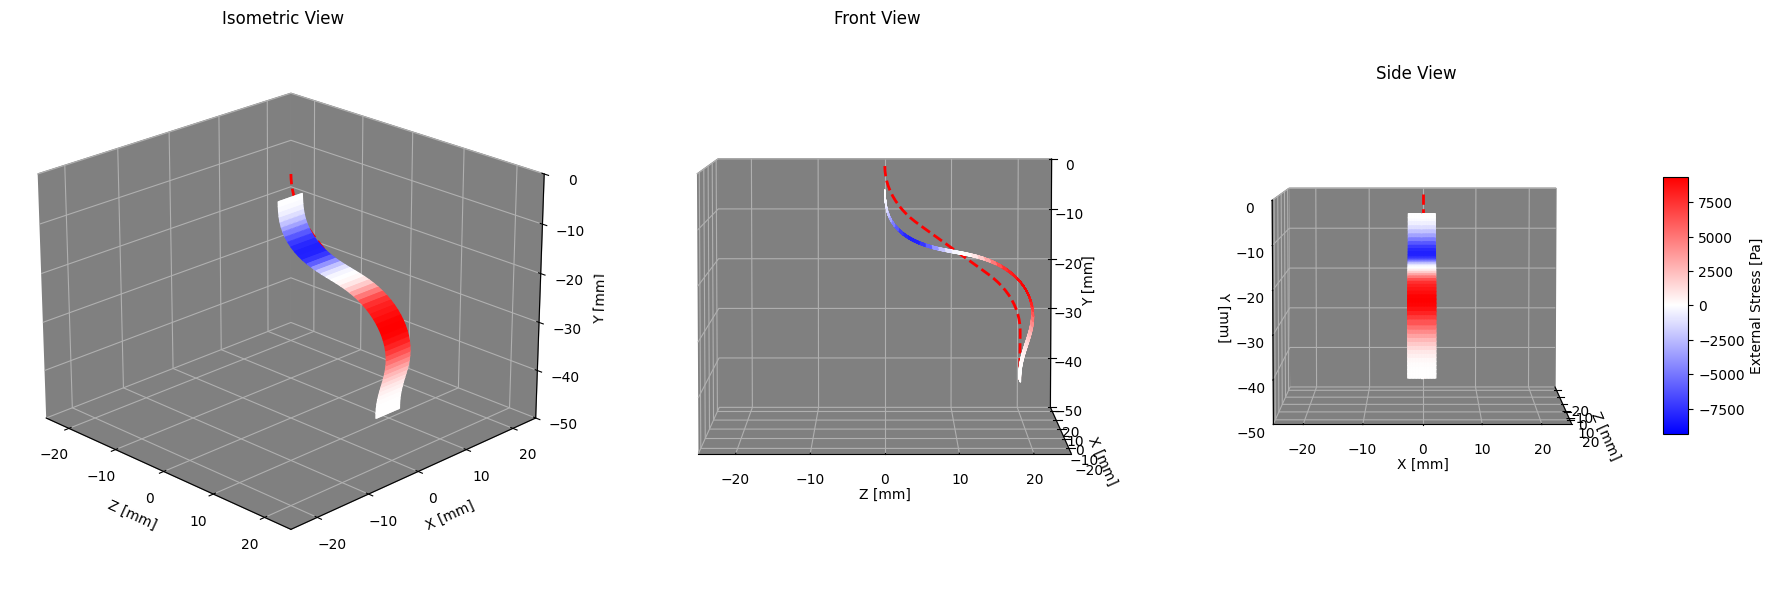

In [5]:
all_solutions = []
all_sleeves = []
last_frame = 49


for idx in range(last_frame+1):
    
    with open(f"result/simulation_data_{idx}.pickle", 'rb') as handle:
        ribbon_output_list_read = pickle.load(handle)
    
    with open(f"result/simulation_data_sleeve_{idx}.pickle", 'rb') as handle:
        sleeve_output_list_read = pickle.load(handle)

    all_solutions.append(process_solution_elastica(ribbon_output_list_read, base_length=base_length[idx]))
    all_sleeves.append(process_solution_elastica_sleeve(sleeve_output_list_read))
    
animate_stress_field_3views(
    all_solutions=all_solutions,
    all_sleeves=all_sleeves,
    all_path = paths_points,
    lengths=base_length, 
    a=5,
    max_frame=last_frame,
    n_points=20,
    interval=4000  
)